In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv('../data/mitbih_train.csv', header=None)
test_df = pd.read_csv('../data/mitbih_test.csv', header=None)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
train_df.shape

(87554, 188)

In [4]:
train_df[187].value_counts()

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64

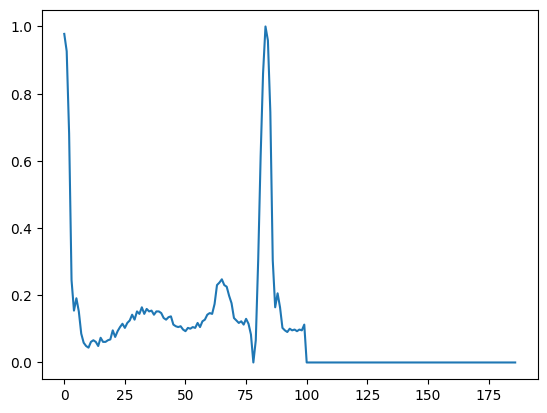

In [5]:
import matplotlib.pyplot as plt

sample = train_df.iloc[0, :-1]
plt.plot(sample)
plt.show()

In [6]:
train_df.shape

(87554, 188)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 125.6 MB


In [8]:
train_df[187].value_counts()

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64

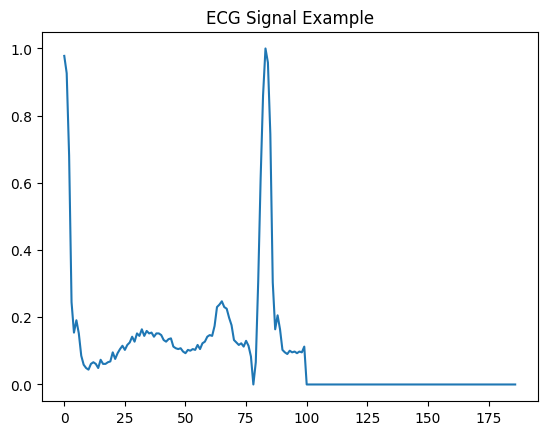

In [9]:
import matplotlib.pyplot as plt

sample = train_df.iloc[0, :-1]  # semua kolom kecuali label

plt.plot(sample)
plt.title("ECG Signal Example")
plt.show()

In [10]:
train_df[187] = train_df[187].apply(lambda x: 0 if x == 0 else 1)
test_df[187] = test_df[187].apply(lambda x: 0 if x == 0 else 1)

In [11]:
train_df[187].value_counts()

187
0    72471
1    15083
Name: count, dtype: int64

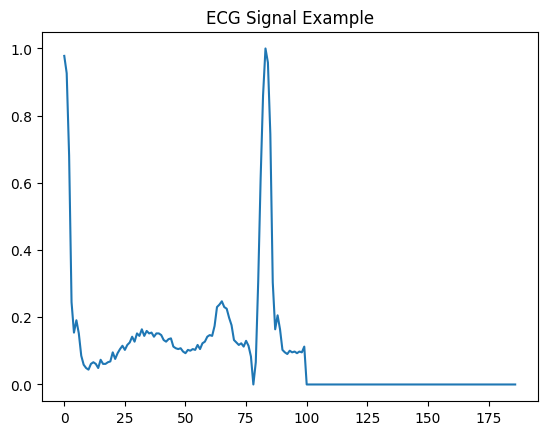

In [12]:
import matplotlib.pyplot as plt

sample = train_df.iloc[0, :-1]

plt.plot(sample)
plt.title("ECG Signal Example")
plt.show()

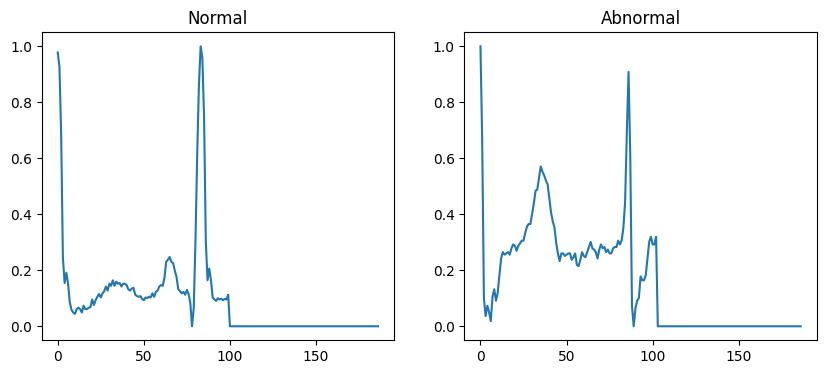

In [13]:
normal = train_df[train_df[187] == 0].iloc[0, :-1]
abnormal = train_df[train_df[187] == 1].iloc[0, :-1]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(normal)
plt.title("Normal")

plt.subplot(1,2,2)
plt.plot(abnormal)
plt.title("Abnormal")

plt.show()

In [14]:
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9050794810889823


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[17752   366]
 [ 1712  2062]]


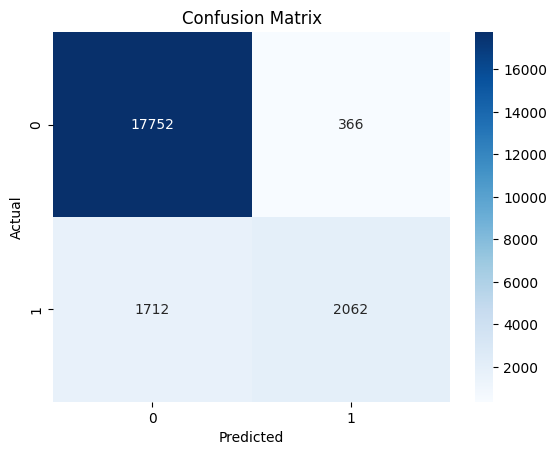

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()